In [1]:
import matplotlib.pyplot as plt

In [2]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
from desc.examples import get


## Inputs
eq = desc.io.load("equil_G1600_DESC_fixed.h5")
# eq = get('HELIOTRON')

# rhos = np.sqrt(np.linspace(0.1,0.9,20)) # rho = sqrt(s)
rhos = np.linspace(0.1,0.9,5)
alphas = np.linspace(0,2*np.pi,3)
# pitch_invs = None
N=0
num_transit = 6
wd_blur = 1.2
num_pitch = 2
pitch_invs = np.linspace(5.95,5.96,num_pitch)
##

In [3]:
obj = TrappedResonance(
                        eq,
                        rho=rhos,
                        alpha=alphas,
                        N=N, # helicity integer
                        n_max=1,
                        num_transit=num_transit,
                        wd_blur=wd_blur,
                        num_pitch=num_pitch,
                        pitch_method=2,
                        pitch_invs=pitch_invs,
                        STAB_SACRIFICE=False, # True = sacrifice Omega_eta' for numerical stability,
                        DEBUG=True
                      )
obj.build()
value = obj.compute(eq.params_dict)

Precomputing transforms


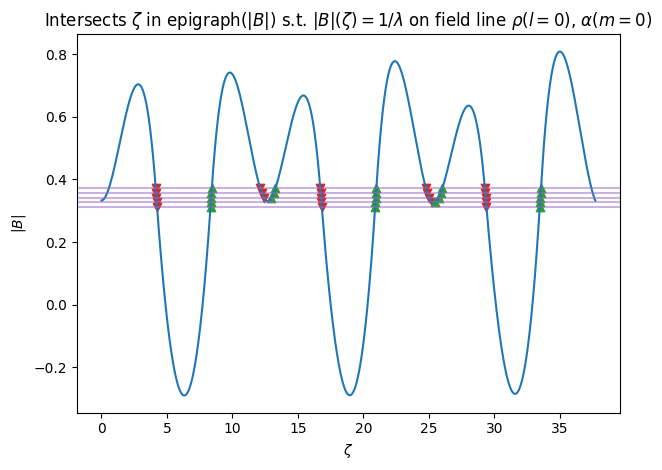

In [4]:
# Plot field line
from desc.integrals.bounce_integral import Bounce1D

num_transit = 6
from desc.examples import get

eq = get('HELIOTRON')

eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rhos, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0,2*np.pi*num_transit,10), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)

data = eq.compute(
    Bounce1D.required_names + ["min_tz |B|", "max_tz |B|", "g_zz"], grid=grid
)
# Make the bounce integration operator.
bounce1 = Bounce1D(grid.source_grid, data, check=True)
pitch_inv, _ = bounce1.get_pitch_inv_quad(
    min_B=grid.compress(data["min_tz |B|"]),
    max_B=grid.compress(data["max_tz |B|"]),
    num_pitch=5, # currently pitch is manually set in this function
)
l=0
m=0
fig, ax = bounce1.plot(l, m, pitch_inv[l], include_legend=False, show=True) # field line plot

In [3]:
# Average ignoring zero values
from desc.utils import safediv
def npmean_nz(x,axis=0):
    mask = x!=0.0
    count = np.sum(mask,axis) # how many wells that are not 0
    return safediv(np.sum(x,axis=axis) , count)
    # return np.sum(x,axis=axis) / count

In [4]:
# 1. Is f_b doing what we want it to do?

wd = value['wd']
omega_arr = value['omega_arr'] # := (rho,Bc,well)
# omega_arr = npmean_nz(omega_arr,axis=-1) # := (rho,Bc)
# omega_arr = omega_arr[:,0] # := (rho)
omega_arr = omega_arr[:,0,0] # := (rho)

rhos = value['rhos'] # := (rho,well)
rhos = npmean_nz(rhos,axis=-1) # := (rho)

f_b = value['f_b'] # := (rho,Bc,well,res)
# f_b = npmean_nz(f_b,axis=-2) # := (rho,Bc,res)
# f_b = f_b[:,0,:] # := (rho,res)
f_b = f_b[:,0,0,:] # := (rho,res)

res_arr = value['res_arr'] # := (res)

fig1,ax1 = plt.subplots()
for i in range(0,f_b.shape[-1]):
    # if res_arr[i] != np.pi or res_arr[i] == 0 or res_arr[i] == 1:
    if res_arr[i] == 0 or res_arr[i] == 1:
        ax1.plot(rhos,f_b[:,i],'-o',label='m/n = '+str(res_arr[i]))

# ax1.set_xlabel(r'$\Omega_\eta$')
ax1.set_xlabel(r'$\rho$')
ax1.set_ylabel(r'$f_b$')
ax1.legend(loc='lower right',bbox_to_anchor=(1.3, 0))

fig,ax = plt.subplots()
ax.plot(rhos,omega_arr,'-o')
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'$\Omega_\eta$')
ax.plot([0,1],[0,0],'--')
ax.plot([0,1],[1,1],'--')
ax.set_ylim([-0.1,0.1])

NameError: name 'value' is not defined

In [6]:
# 2. Is the island width correct?
'''
Delta psi = 4^4 (  ( int_0^{2*pi}psi_drift^2 ) / (Omega_eta^2 pi n^2) )  ^(1/4)
rho = sqrt(psi/psi_a)
See Overleaf for complete derivation
'''

import numpy as np

Deltarho_4 = value['Deltarho_4'] # := (rho,Bcrit,well,res)

eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid_psi = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rhos, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
rhos_broad = np.broadcast_to(rhos[:,None,None,None],Deltarho_4.shape) # := (rho,Bcrit,well,res)
psi = eq.compute("Psi",grid=grid_psi)
psi = psi['Psi']
psi_a = psi[-1]

Deltarho = (2 / (psi_a*rhos_broad)) * ( value['Deltarho_4'] / (value['Omega_prime']*np.pi) ) ** (1/4) # := (rho,Bcrit,well,res)
Deltarho = Deltarho[:,:,0,:] # only look at first well



(45, 2, 21)


Text(0.5, 1.0, '$B_{crit} = 5.95$ T')

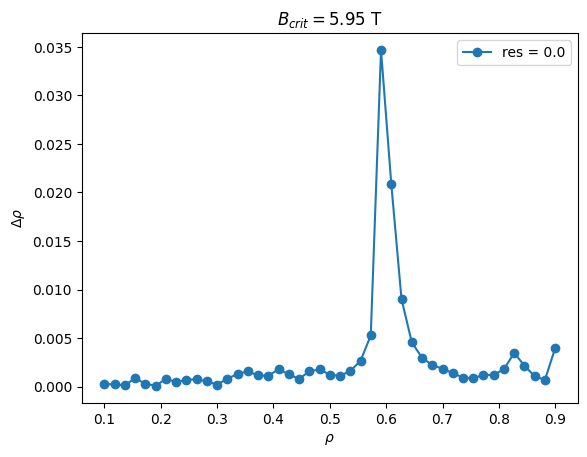

In [7]:
print(Deltarho.shape)
fig2,ax2 = plt.subplots()
ax2.plot(rhos,Deltarho[:,0,0],'-o',label='res = '+ str(value['res_arr'][0]))
ax2.legend()
ax2.set_xlabel(r'$\rho$')
ax2.set_ylabel(r'$\Delta\rho$')
ax2.set_title(r'$B_{crit} = 5.95$ T')

In [ ]:
# 3. Does increasing resolution of rho, alpha, Bcrit individually cause the objective function to asymptote to a single value?

# First test RHO resolution increases
val_list = []
resol_list = []

import numpy as np

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
from desc.examples import get


## Inputs
eq = get('HELIOTRON')
# eq = desc.io.load("equil_G1600_DESC_fixed.h5")

for i in np.linspace(1,8,10):
    rhos = np.linspace(0.1,0.9,int(20*i))
    alphas = np.linspace(0,2*np.pi,3)
    N=0
    num_transit = 6
    wd_blur = 1.2
    num_pitch = 16

    obj = TrappedResonance(
                        eq,
                        rho=rhos,
                        alpha=alphas,
                        N=N, # helicity integer
                        n_max=1,
                        num_transit=num_transit,
                        wd_blur=wd_blur,
                        num_pitch=num_pitch,
                        pitch_method=1,
                        # pitch_invs=pitch_invs,
                        STAB_SACRIFICE=True, # True = sacrifice Omega_eta' for numerical stability
                        DEBUG=False
                      )
    obj.build()
    val_list.append(obj.compute(eq.params_dict))
    resol_list.append(len(rhos))


Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms
Precomputing transforms


In [ ]:
fig3,ax3 = plt.subplots()
ax3.plot(resol_list,val_list)
ax3.set_xlabel("Number of Flux Surfaces")
ax3.set_ylabel(r'Value of $f$')

In [15]:
# Check reverse shear or not
eq = desc.io.load('equil_G1600_DESC_fixed.h5')
rho_iota = np.linspace(0.01,0.99,30)
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho_iota, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
eqiota = eq.compute('iota',grid=grid)['iota']


Text(0, 0.5, '$\\iota$')

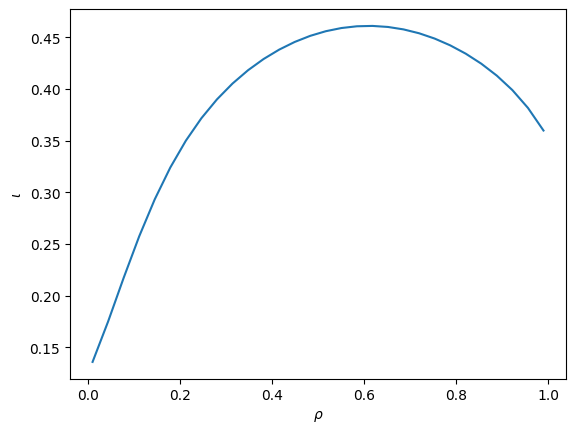

In [17]:
# Iota plot
fig,ax = plt.subplots()
ax.plot(rho_iota,eqiota)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'$\iota$')

In [18]:
# Check reverse shear or not
eq = desc.io.load('desc_eq_beta2.5_QA.h5')
rho_iota = np.linspace(0.01,0.99,30)
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho_iota, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
eqiota = eq.compute('iota',grid=grid)['iota']


Text(0, 0.5, '$\\iota$')

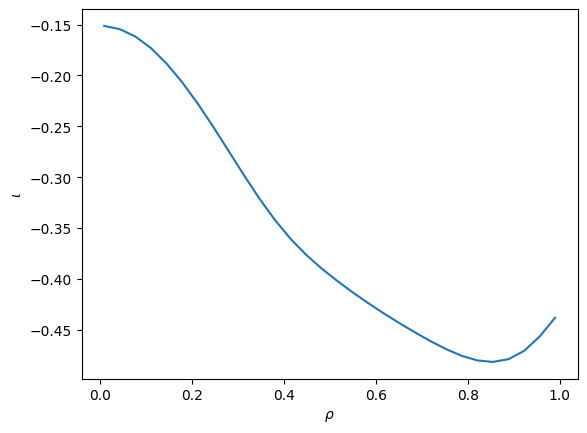

In [19]:
fig,ax = plt.subplots()
ax.plot(rho_iota,eqiota)
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'$\iota$')